In [7]:
from diffusers import (
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    UniPCMultistepScheduler
)
import numpy as np
import torch
from pathlib import Path 
import numpy as np 
from diffusers.utils import load_image

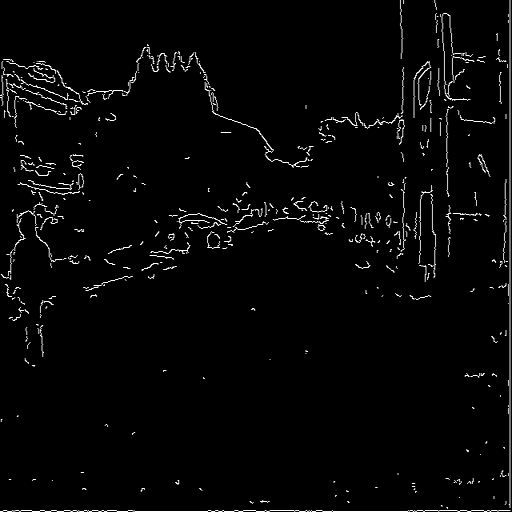

In [8]:
edge_image = load_image("outputs/edges.png")
edge_image.resize((512,512))

In [9]:
# Control Net model
try:
    controlnet = ControlNetModel.from_pretrained(
        "lllyasviel/sd-controlnet-canny", 
        torch_dtype=torch.float16,
        use_safetensors=True,
        device="mps"
    )
except Exception as error:
    print (error)

print ('load controlnet')

# --------- LOAD MAIN PIPELINE ----------
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", 
    controlnet=controlnet, 
    torch_dtype=torch.float16,
    use_safetensors=True
)

device = "mps" if torch.backends.mps.is_available() else "cpu"

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

load controlnet


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [20]:
# you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1

prompt = """
photorealistic, realistic image, high resolution, ultra detailed,
accurate textures, natural lighting, soft shadows,
DSLR photograph, sharp focus, cinematic lighting, 8k, high dynamic range
"""

negative_prompt = """
blurry, low quality, deformed, cartoon, painting, illustration,
oversaturated, monochrome, distorted geometry, unrealistic lighting
"""

out = pipe(
    prompt="",
    negative_prompt=negative_prompt,
    image=load_image("outputs/edges.png"),
    num_inference_steps=34,   # reduced for speed
    controlnet_conditioning_scale=1.0,
    guidance_scale=7.5,
    strength=1
)

# --------- SAVE RESULT ----------
out.images[0].save("outputs/result.png")

  0%|          | 0/34 [00:00<?, ?it/s]

In [6]:
out.images[0].save("outputs/result.png")